# MeshGraphNet (MGN) Beam Dynamics Demo

This notebook demonstrates the complete pipeline for training a MeshGraphNet to predict beam elastodynamics:

1. **Data Preprocessing**: Converting raw simulation data into graph format
2. **Dataset Loading**: Creating PyTorch Geometric datasets
3. **Model Architecture**: Building the MeshGraphNet
4. **Training**: Training loop with loss tracking
5. **Evaluation**: Rollout testing and visualization
6. **Visualization**: Creating comparison GIFs

The MeshGraphNet learns to predict:
- Node accelerations (3D)
- Von Mises stress (scalar)

given the current state of a deforming beam mesh.

## 1. Setup and Imports

### Data Organization

This notebook uses data from the Hugging Face repository: `kevinsteiner/elastic-beam-3d`

**Data Structure:**
```
elastic-beam-3d/
├── raw/
│   └── single-direction-beam/
│       ├── small/
│       │   ├── train/graphs/
│       │   ├── val/graphs/
│       │   └── test/graphs/
│       ├── medium/
│       └── large/
└── processed/
    ├── small/
    │   ├── train/
    │   │   ├── graphs/
    │   │   └── stats/
    │   ├── val/graphs/
    │   └── test/graphs/
    ├── medium/
    └── large/
```

The notebook will:
1. Download raw data from Hugging Face
2. Preprocess it (normalize, compute features)
3. Save processed data locally for training

In [1]:
import os
import json
import time
import shutil
from pathlib import Path
from dataclasses import dataclass
from typing import Literal

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch_scatter import scatter_add
from torch_geometric.data import Data, Batch, Dataset
from torch_geometric.loader import DataLoader

import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import imageio

from tqdm import tqdm
import wandb

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set matplotlib to non-interactive mode for faster plotting
matplotlib.use("Agg")
plt.ioff()

Using device: cuda


### Weights & Biases (wandb) Setup (Optional)

This notebook uses [Weights & Biases](https://wandb.ai) for experiment tracking and visualization.

**Setup Options:**

1. **With wandb tracking** (recommended):
   ```bash
   pip install wandb
   wandb login
   ```
   Then set `use_wandb=True` when creating the trainer.

2. **Without wandb** (local tracking only):
   - Set `use_wandb=False` when creating the trainer
   - I think in this case no login required, all metrics saved locally only

Wandb will automatically log:
- Training and validation losses
- Rollout errors
- Comparison GIFs
- Volume conservation plots

## 2. Download Data from Hugging Face

First, we'll download the raw simulation data from the Hugging Face repository.

In [2]:
from huggingface_hub import snapshot_download

# Download the dataset from Hugging Face
# This will download the entire repository to a local cache directory
repo_id = "kevinsteiner/elastic-beam-3d"
local_dir = "./elastic-beam-3d"

print(f"Downloading dataset from {repo_id}...")
snapshot_download(
    repo_id=repo_id,
    repo_type="dataset",
    local_dir=local_dir,
    local_dir_use_symlinks=False,
    ignore_patterns=["raw/large/**"],  # Ignore large files for faster download
)
print(f"Dataset downloaded to {local_dir}")

# Verify the data structure
raw_data_path = Path(local_dir) / "raw" / "single-direction-beam"
print(f"\nAvailable dataset sizes:")
for size_dir in raw_data_path.iterdir():
    if size_dir.is_dir():
        print(f"  - {size_dir.name}")
        for split_dir in size_dir.iterdir():
            if split_dir.is_dir():
                graphs_dir = split_dir / "graphs"
                if graphs_dir.exists():
                    num_files = len(list(graphs_dir.glob("*.pt")))
                    print(f"    - {split_dir.name}: {num_files} graph files")

/home/runai-home/.local/lib/python3.10/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching ... files: 0it [00:00, ?it/s]

Dataset downloaded to ./elastic-beam-3d

Available dataset sizes:
  - large
    - test: 1 graph files
    - train: 1000 graph files
    - val: 1 graph files
  - medium
    - test: 1 graph files
    - train: 216 graph files
    - val: 1 graph files
  - small
    - test: 1 graph files
    - train: 54 graph files
    - val: 1 graph files


## 3. Data Preprocessing Utilities

These functions handle:
- Computing statistics for normalization
- Building node and edge features from mesh data
- Normalizing/denormalizing data

In [3]:
@dataclass
class Stats:
    """Statistics for data normalization."""
    mean: torch.Tensor
    std: torch.Tensor

    def to_dict(self):
        return {"mean": self.mean.tolist(), "std": self.std.tolist()}

    @classmethod
    def from_dict(cls, d):
        return cls(mean=torch.tensor(d["mean"]), std=torch.tensor(d["std"]))

    def to(self, device):
        self.mean = self.mean.to(device)
        self.std = self.std.to(device)
        return self


def compute_stats(tensor_list) -> Stats:
    """Compute mean and std statistics from a list of tensors."""
    sum_val = 0
    sum_sq = 0
    count = 0
    for tensor in tensor_list:
        sum_val += tensor.sum(dim=0)
        sum_sq += (tensor**2).sum(dim=0)
        count += tensor.shape[0]
    mean = sum_val / count
    var = (sum_sq / count) - (mean**2)
    std = torch.sqrt(var)
    return Stats(mean=mean, std=std)


def normalize(tensor: torch.Tensor, stats: Stats, eps: float = 1e-8) -> torch.Tensor:
    """Normalize tensor using statistics."""
    return (tensor - stats.mean) / (stats.std + eps)


def denormalize(tensor: torch.Tensor, stats: Stats, eps: float = 1e-8) -> torch.Tensor:
    """Denormalize tensor using statistics."""
    return tensor * (stats.std + eps) + stats.mean

In [4]:
def compute_von_mises_3d(stress_9):
    """Compute von Mises stress from 9-component stress tensor."""
    sxx = stress_9[:, 0]
    sxy = stress_9[:, 1]
    sxz = stress_9[:, 2]
    syx = stress_9[:, 3]
    syy = stress_9[:, 4]
    syz = stress_9[:, 5]
    szx = stress_9[:, 6]
    szy = stress_9[:, 7]
    szz = stress_9[:, 8]
    vm = 0.5 * (
        (sxx - syy) ** 2
        + (syy - szz) ** 2
        + (szz - sxx) ** 2
        + 6.0 * (sxy**2 + syz**2 + sxz**2)
    )
    return torch.sqrt(vm)


def volume(V: torch.Tensor, T: torch.Tensor) -> torch.Tensor:
    """Calculate volumes of tetrahedra.
    
    Args:
        V: Vertex positions (N, 3)
        T: Tetrahedra connectivity (M, 4)
    
    Returns:
        Volumes for each tetrahedron (M,)
    """
    a = V[T[:, 0], :]
    b = V[T[:, 1], :]
    c = V[T[:, 2], :]
    d = V[T[:, 3], :]
    vols = -torch.sum(torch.mul(a - d, torch.cross(b - c, c - d, dim=1)), dim=1) / 6.0
    return vols

In [5]:
def calculate_kinematics(x: Tensor, dt: float) -> tuple[Tensor, Tensor]:
    """Calculate velocities and accelerations from positions.
    
    Args:
        x: Positions over time (T, N, 3)
        dt: Time step size
    
    Returns:
        v: Velocities (T, N, 3)
        a: Accelerations (T-1, N, 3)
    """
    v0 = torch.zeros(*x[0].shape, device=x.device, dtype=x.dtype).unsqueeze(0)
    dx = x[1:] - x[:-1]
    v_steps = dx / dt
    v = torch.cat([v0, v_steps], dim=0)
    dv = v[1:] - v[:-1]
    a = dv / dt
    return v, a


def build_valued_node_features(
    x: Tensor, v: Tensor, u: Tensor, node_force: Tensor
) -> Tensor:
    """Build valued node features: [position, velocity, rest_position, node_force]"""
    return torch.concat([x, v, u, node_force], dim=1)


def build_edge_features(x: Tensor, u: Tensor, edge_index: Tensor) -> Tensor:
    """Build edge features from node positions and rest positions.
    
    Features: [relative_position, relative_position_norm, 
               rest_relative_position, rest_relative_position_norm]
    """
    src, dst = edge_index
    xij = x[dst] - x[src]
    uij = u[dst] - u[src]
    xij_norm = torch.norm(xij, dim=1).unsqueeze(1)
    uij_norm = torch.norm(uij, dim=1).unsqueeze(1)
    return torch.concat([xij, xij_norm, uij, uij_norm], dim=1)

### Data Preprocessing Function

This function loads raw simulation data and converts it to graph format:
- Loads trajectory files
- Computes velocities and accelerations
- Builds node and edge features
- Normalizes features
- Saves preprocessed graphs

In [6]:
def preprocess_data(
    data_dir: Path,
    split: str,
    dataset_size: str = "small",
    noise_scale: float = 0.0,
    dt: float = 0.08,
    recalc_velocities: bool = False,
    base_dir: Path = Path("./elastic-beam-3d"),
):
    """Preprocess simulation data into graph format.
    
    Args:
        data_dir: Directory containing raw simulation data (e.g., raw/single-direction-beam/small)
        split: 'train', 'val', or 'test'
        dataset_size: 'small', 'medium', or 'large'
        noise_scale: Amount of noise to add during training
        dt: Time step size
        recalc_velocities: Whether to recalculate velocities from positions
        base_dir: Base directory for elastic-beam-3d data
    """
    SEED = 42
    torch.manual_seed(SEED)

    # Input path: raw/single-direction-beam/{size}/{split}/graphs
    graphs_dir = data_dir / split / "graphs"
    filenames = list(graphs_dir.glob("*.pt"))

    out_graphs = []
    categorical_node_features = []
    valued_node_features = []
    edge_features = []
    traj_idx = []
    targets = []
    
    # Load stats if not training
    if split != "train":
        stats_path = base_dir / "processed" / dataset_size / "train" / "stats" / "stats.json"
        if not stats_path.exists():
            raise FileNotFoundError(
                f"Stats file not found at {stats_path}. "
                f"Please preprocess the training data first."
            )
        with open(stats_path, "r") as f:
            stats = json.load(f)
        node_stats = Stats.from_dict(stats["node"])
        edge_stats = Stats.from_dict(stats["edge"])
        target_stats = Stats.from_dict(stats["target"])
        
    for idx, filename in enumerate(filenames):
        print(f"Processing file: {filename.name} ({idx + 1}/{len(filenames)})")
        dataloader = torch.load(filename, weights_only=False)
        graphs = []
        for data in dataloader:
            graph = data.to("cpu")
            graphs.append(graph)
        whole_trajectory_batch = Batch.from_data_list(graphs)
        len_traj = len(graphs)

        # Extract positions over time
        x = whole_trajectory_batch.x.reshape(len_traj, -1, 3)
        v, a = calculate_kinematics(x, dt)

        # Add noise to training data
        if split == "train":
            noise = noise_scale * torch.randn_like(v)
            x = x + noise
            v = v - noise / dt  # adjust velocity accordingly

        v_next = v[1:]
        x_next = x[1:]

        u = x[0]  # Rest mesh position
        all_node_force = whole_trajectory_batch.x_node_force.reshape(len_traj, -1, 3)
        boundary_condition = graphs[0].x_bc  # 1 = fixed, 0 = free
        
        for t, graph in enumerate(graphs):
            if t > 48:  # Limit trajectory length
                break
            traj_idx.append(idx)
            _node_force = all_node_force[t]
            _x = x[t]
            _v = v[t]
            _a = a[t]

            _categorical_node_attr = boundary_condition
            _node_attr = build_valued_node_features(_x, _v, u, _node_force)
            _edge_attr = build_edge_features(_x, u, graph.edge_index)

            # Compute von Mises stress
            von_mises = torch.log(
                compute_von_mises_3d(graph.y_sig_t).unsqueeze(1) + 1e-6
            )

            if split != "train":
                # Use precomputed stats for validation
                edge_attr = normalize(_edge_attr, edge_stats)
                vector_node_attr = normalize(_node_attr, node_stats)
                categorical_node_attr = _categorical_node_attr
                node_attr = torch.concat(
                    [categorical_node_attr, vector_node_attr], dim=1
                )

                out_graphs.append(
                    Data(
                        x=node_attr,
                        edge_attr=edge_attr,
                        edge_index=graph.edge_index,
                        t=graph.time,
                        x_pos_t=x[t],
                        x_vel_t=v[t],
                        node_force=all_node_force[t],
                        node_force_next=all_node_force[t + 1],
                        x_next=x_next[t],
                        v_next=v_next[t],
                        y_acc_t=a[t],
                        y_von_mises=von_mises,
                        x_element_connectivity=graph.x_element_connectivity,
                        u=u,
                    )
                )
            else:
                # Accumulate for stats computation
                categorical_node_features.append(boundary_condition)
                valued_node_features.append(
                    build_valued_node_features(_x, _v, u, _node_force)
                )
                edge_features.append(build_edge_features(_x, u, graph.edge_index))
                out_graphs.append(
                    Data(
                        edge_index=graph.edge_index,
                        t=graph.time,
                        y_acc_t=_a,
                        x_pos_t=_x,
                        x_vel_t=_v,
                    )
                )
                targets.append(torch.concat([_a, von_mises], dim=1))
                
    if split == "train":
        # Compute and save statistics
        node_stats = compute_stats(valued_node_features)
        edge_stats = compute_stats(edge_features)
        target_stats = compute_stats(targets)

        stats = {
            "node": node_stats.to_dict(),
            "edge": edge_stats.to_dict(),
            "target": target_stats.to_dict(),
        }
        # Save to: processed/{size}/train/stats/stats.json
        stats_dir = base_dir / "processed" / dataset_size / "train" / "stats"
        stats_dir.mkdir(parents=True, exist_ok=True)
        with open(stats_dir / "stats.json", "w") as f:
            json.dump(stats, f, indent=4)
        print(f"Stats saved to {stats_dir / 'stats.json'}")

        # Normalize and assign features
        for t in range(len(out_graphs)):
            _valued_node_features = normalize(valued_node_features[t], node_stats)
            _edge_features = normalize(edge_features[t], edge_stats)
            _targets = normalize(targets[t], target_stats)
            out_graphs[t].x = torch.concat(
                [categorical_node_features[t], _valued_node_features], dim=1
            )
            out_graphs[t].edge_attr = _edge_features
            out_graphs[t].y = _targets

    # Save preprocessed graphs to: processed/{size}/{split}/graphs/graph_XX.pt
    save_dir = base_dir / "processed" / dataset_size / split / "graphs"
    save_dir.mkdir(parents=True, exist_ok=True)
    for traj in set(traj_idx):
        print(f"Saving trajectory: {traj}")
        graphs = [graph for idx, graph in zip(traj_idx, out_graphs) if idx == traj]
        print(f"  Length: {len(graphs)} timesteps")
        file_path = save_dir / f"graph_{traj:02d}.pt"
        torch.save(graphs, file_path)
        
    print(f"Preprocessing complete for {split} split!")
    print(f"Saved to: {save_dir}")

### Run Preprocessing

This cell will preprocess all splits (train, val, test) for the selected dataset size.

**Note:** This step can take time depending on the dataset size. The processed data will be saved to the `processed/` folder.

In [7]:
# Run preprocessing
# Choose dataset size: 'small', 'medium', or 'large'
DATASET_SIZE = "small"

base_dir = Path("./elastic-beam-3d")
raw_data_dir = base_dir / "raw" / "single-direction-beam" / DATASET_SIZE

print(f"Preprocessing {DATASET_SIZE} dataset...")
print("=" * 60)

# Preprocess training data
print("\n1. Preprocessing training data...")
preprocess_data(
    data_dir=raw_data_dir,
    split="train",
    dataset_size=DATASET_SIZE,
    noise_scale=0.0003,
    recalc_velocities=True,
    base_dir=base_dir,
)

print("\n2. Preprocessing validation data...")
preprocess_data(
    data_dir=raw_data_dir,
    split="val",
    dataset_size=DATASET_SIZE,
    recalc_velocities=True,
    base_dir=base_dir,
)

print("\n3. Preprocessing test data (if available)...")
test_graphs_dir = raw_data_dir / "test" / "graphs"
if test_graphs_dir.exists():
    preprocess_data(
        data_dir=raw_data_dir,
        split="test",
        dataset_size=DATASET_SIZE,
        recalc_velocities=True,
        base_dir=base_dir,
    )
else:
    print("  No test data found, skipping...")

print("\n" + "=" * 60)
print("Preprocessing complete!")

Preprocessing small dataset...

1. Preprocessing training data...
Processing file: graphsL0.5_W0.06_D0.1_NL8_NW4_ND4_E1000.0_nu0.3_rho1.0_em0.01_ek0.01_Pix0.0_Piy0.25_Piz0.0_T4.0_Tc0.8_Nsteps50.pt (1/54)
Processing file: graphsL0.5_W0.06_D0.1_NL8_NW4_ND4_E1000.0_nu0.3_rho1.0_em0.01_ek0.01_Pix0.0_Piy0.5_Piz0.0_T4.0_Tc0.8_Nsteps50.pt (2/54)
Processing file: graphsL0.5_W0.06_D0.1_NL8_NW4_ND4_E1000.0_nu0.3_rho1.0_em0.01_ek0.01_Pix0.0_Piy0.75_Piz0.0_T4.0_Tc0.8_Nsteps50.pt (3/54)
Processing file: graphsL0.5_W0.06_D0.1_NL8_NW4_ND4_E1000.0_nu0.3_rho1.0_em0.01_ek0.01_Pix0.0_Piy1.25_Piz0.0_T4.0_Tc0.8_Nsteps50.pt (4/54)
Processing file: graphsL0.5_W0.06_D0.1_NL8_NW4_ND4_E1000.0_nu0.3_rho1.0_em0.01_ek0.01_Pix0.0_Piy1.0_Piz0.0_T4.0_Tc0.8_Nsteps50.pt (5/54)
Processing file: graphsL0.5_W0.14_D0.1_NL8_NW4_ND4_E1000.0_nu0.3_rho1.0_em0.01_ek0.01_Pix0.0_Piy0.5_Piz0.0_T4.0_Tc0.8_Nsteps50.pt (6/54)
Processing file: graphsL0.5_W0.06_D0.1_NL8_NW4_ND4_E1000.0_nu0.3_rho1.0_em0.01_ek0.01_Pix0.0_Piy1.5_Piz0.0_T4

## 4. Dataset Loading

Create PyTorch Geometric datasets and dataloaders from the preprocessed data. The large dataset is probably to large to fit into memory. In that case you need to write a lazy loader that only loads a graph from a file if needed.

In [8]:
class InMemoryTimeStepDataset(Dataset):
    """In-memory dataset for graph data.
    
    Loads all preprocessed graphs into memory for fast training.
    """

    def __init__(self, sample_dir):
        self.data = []
        sample_files = sorted(
            [
                os.path.join(sample_dir, f)
                for f in os.listdir(sample_dir)
                if f.startswith("graph_") and f.endswith(".pt")
            ]
        )
        print(f"Found {len(sample_files)} sample files")
        for sample_file in sample_files:
            sample_data = torch.load(
                sample_file, map_location="cpu", weights_only=False
            )
            self.data.extend(sample_data)  # Flatten all time steps into one list
        print(f"Loaded the dataset with {len(self.data)} samples")

    def __getitem__(self, idx):
        return self.data[idx]

    def __len__(self):
        return len(self.data)

In [9]:
# Load datasets from processed folder
DATASET_SIZE = "small"  # Use same size as preprocessing
base_dir = Path("./elastic-beam-3d")
processed_dir = base_dir / "processed" / DATASET_SIZE

train_dataset = InMemoryTimeStepDataset(sample_dir=processed_dir / "train" / "graphs")
test_dataset = InMemoryTimeStepDataset(sample_dir=processed_dir / "val" / "graphs")

# Create dataloaders
batch_size = 16
num_workers = 4
train_dataloader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers
)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Found 54 sample files
Loaded the dataset with 2646 samples
Found 1 sample files
Loaded the dataset with 49 samples
Training samples: 2646
Test samples: 49


## 5. MeshGraphNet Model Architecture

The MeshGraphNet consists of three main components:

1. **Encoder**: Encodes node and edge features into latent space
2. **Processor**: Multiple message-passing layers that update node and edge embeddings
3. **Decoder**: Decodes node embeddings to predict accelerations and stress

In [10]:
def build_mlp_d(
    in_size,
    hidden_size,
    out_size,
    num_layers=1,
    lay_norm=True,
    use_sigmoid=False,
    use_softmax=False,
):
    """Build a multi-layer perceptron with optional layer normalization."""
    if use_sigmoid and use_softmax:
        raise ValueError("Only one of use_sigmoid or use_softmax can be true.")

    layers = [nn.Linear(in_size, hidden_size), nn.ReLU()]

    # Add intermediate layers
    for _ in range(num_layers - 1):
        layers.append(nn.Linear(hidden_size, hidden_size))
        layers.append(nn.ReLU())

    # Add the output layer
    layers.append(nn.Linear(hidden_size, out_size))

    module = nn.Sequential(*layers)

    # Optionally add layer normalization
    if lay_norm:
        module = nn.Sequential(module, nn.LayerNorm(normalized_shape=out_size))

    if use_sigmoid:
        module = nn.Sequential(module, nn.Sigmoid())

    if use_softmax:
        module = nn.Sequential(module, nn.Softmax(dim=-1))

    return module

In [11]:
class Encoder(torch.nn.Module):
    """Encoder for node and edge features."""

    def __init__(self, node_channels, edge_channels, latent_size=128):
        super(Encoder, self).__init__()
        self.edge_encoder = build_mlp_d(
            edge_channels, latent_size, latent_size, num_layers=1, lay_norm=True
        )
        self.node_encoder = build_mlp_d(
            node_channels, latent_size, latent_size, num_layers=1, lay_norm=True
        )

    def forward(self, node_features, edge_features):
        node_embedding = self.node_encoder(node_features)
        edge_embedding = self.edge_encoder(edge_features)
        return node_embedding, edge_embedding

In [12]:
class GraphNetBlock(torch.nn.Module):
    """Graph network block for message passing.
    
    Performs one round of message passing:
    1. Update edge embeddings based on sender and receiver nodes
    2. Aggregate messages at each node
    3. Update node embeddings
    """

    def __init__(
        self,
        in_size_edge_MLP,
        in_size_node_MLP,
        latent_size=128,
    ):
        super(GraphNetBlock, self).__init__()
        self._latent_size = latent_size

        # Edge MLP: updates edge embeddings
        self.edge_net = build_mlp_d(
            in_size_edge_MLP, latent_size, latent_size, lay_norm=True
        )

        # Node MLP: updates node embeddings
        self.node_net = build_mlp_d(
            in_size_node_MLP, latent_size, latent_size, lay_norm=True
        )

    def forward(self, edge_index, node_embedding, edge_embedding):
        senders, receivers = edge_index
        num_nodes = node_embedding.shape[0]

        # Update edge embeddings
        edge_attr_ = self.edge_net(
            torch.hstack(
                (node_embedding[senders], node_embedding[receivers], edge_embedding)
            )
        )

        # Aggregate received messages at each node
        agg_received_edges = scatter_add(
            edge_attr_, receivers.long(), dim=0, dim_size=num_nodes
        )

        # Update node embeddings
        node_attr_ = self.node_net(torch.hstack((agg_received_edges, node_embedding)))

        # Residual connections
        new_node_embedding = node_attr_ + node_embedding
        new_edge_embedding = edge_attr_ + edge_embedding

        return new_node_embedding, new_edge_embedding

In [13]:
class Decoder(torch.nn.Module):
    """Decoder to predict acceleration and von Mises stress."""

    def __init__(self, latent_size=128):
        super(Decoder, self).__init__()
        self.acc_decoder = build_mlp_d(latent_size, latent_size, 3, lay_norm=False)
        self.von_mises_decoder = build_mlp_d(
            latent_size, latent_size, 1, lay_norm=False
        )

    def forward(self, node_embedding):
        decoded_acc = self.acc_decoder(node_embedding)
        decoded_von_mis = self.von_mises_decoder(node_embedding)
        pred = torch.hstack((decoded_acc, decoded_von_mis))
        return pred

In [14]:
class MeshGraphNet(nn.Module):
    """MeshGraphNet Model.
    
    Processes mesh data through encoding, message passing, and decoding
    to predict node accelerations and stress.
    """

    def __init__(
        self,
        node_channels: int,
        edge_channels: int,
        latent_size: int = 128,
        num_msgs=3,
    ):
        super(MeshGraphNet, self).__init__()

        # Encoder
        self.encoder = Encoder(
            node_channels=node_channels,
            edge_channels=edge_channels,
            latent_size=latent_size,
        )

        # Message-passing layers
        self.processer_list = nn.ModuleList(
            [
                GraphNetBlock(
                    latent_size=latent_size,
                    in_size_edge_MLP=3 * latent_size,
                    in_size_node_MLP=2 * latent_size,
                )
                for _ in range(num_msgs)
            ]
        )

        # Decoder
        self.decoder = Decoder(latent_size)

    def forward(self, ingraph):
        node_features = ingraph.x
        edge_features = ingraph.edge_attr
        edge_index = ingraph.edge_index

        # Encode
        node_embedding, edge_embedding = self.encoder(node_features, edge_features)

        # Process through message-passing layers
        for processor in self.processer_list:
            node_embedding, edge_embedding = processor(
                edge_index, node_embedding, edge_embedding
            )

        # Decode
        pred = self.decoder(node_embedding)

        return pred

In [15]:
# Initialize model
node_channels = 13  # 1 (boundary) + 3 (position) + 3 (velocity) + 3 (rest position) + 3 (force)
edge_channels = 8   # 3 (relative position) + 1 (norm) + 3 (rest relative position) + 1 (norm)
num_messages = 8
latent_dim = 128

torch.manual_seed(42)
model = MeshGraphNet(
    node_channels=node_channels,
    edge_channels=edge_channels,
    latent_size=latent_dim,
    num_msgs=num_messages,
)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 995,716


## 6. Rollout and Evaluation Utilities

Functions for performing model rollouts (autoregressive prediction) and evaluation.

In [16]:
def mae(target, pred):
    """Mean absolute error."""
    return torch.mean(torch.abs(target - pred))


def build_mgn_graph_from_timestep(
    simulation_graph: Data,
    x_new: torch.Tensor,
    v_new: torch.Tensor,
    u: torch.Tensor,
    node_stats: Stats,
    edge_stats: Stats,
    target_stats: Stats,
):
    """Build a graph for the next timestep from predicted state."""
    input_graph = simulation_graph

    boundary_condition = simulation_graph.x[:, 0]
    node_force = simulation_graph.node_force_next

    categorical_node_features = boundary_condition.unsqueeze(1)
    valued_node_features = torch.concat([x_new, v_new, u, node_force], dim=1)

    src, dst = simulation_graph.edge_index
    xij = x_new[dst] - x_new[src]
    xij_norm = torch.norm(xij, dim=1).unsqueeze(1)
    uij = u[dst] - u[src]
    uij_norm = torch.norm(uij, dim=1).unsqueeze(1)

    edge_features = torch.concat([xij, xij_norm, uij, uij_norm], dim=1)

    _edge_attr = normalize(edge_features, edge_stats)
    _x = torch.concat(
        [
            categorical_node_features,
            normalize(valued_node_features, node_stats),
        ],
        dim=1,
    )
    _x[-1] = simulation_graph.x[-1]  # Keep force node features unchanged
    input_graph.x = _x
    input_graph.edge_attr = _edge_attr
    input_graph.x_pos_t = x_new
    input_graph.x_vel_t = v_new
    input_graph.node_force = node_force
    return input_graph

In [17]:
def do_rollout(
    model: torch.nn.Module,
    test_loader: DataLoader,
    node_stats: Stats,
    edge_stats: Stats,
    target_stats: Stats,
    dt: float,
    device: torch.device,
    skip_first: int = 0,
    rollout_steps: int = 99999999,
):
    """Perform autoregressive rollout using the model.
    
    Args:
        model: Trained MeshGraphNet
        test_loader: DataLoader for test data
        node_stats, edge_stats, target_stats: Normalization statistics
        dt: Time step size
        device: Computation device
        skip_first: Number of initial steps to skip
        rollout_steps: Maximum number of steps to rollout
    
    Returns:
        true_rollout: List of ground truth graphs
        pred_rollout: List of predicted graphs
    """
    with torch.no_grad():
        true_rollout = []
        pred_rollout = []
        u = None

        for t, graph in enumerate(test_loader):
            if u is None:
                u = graph.u
            if t < skip_first:
                continue
            if t > rollout_steps:
                break
            if t == skip_first:
                input_graph = graph

            # Predict
            pred = model(input_graph.to(device))
            input_graph = input_graph.cpu()
            pred = pred.cpu()

            pred_denorm = denormalize(pred, target_stats)
            von_mises_true = graph.y_von_mises

            a = pred_denorm[:, :3]
            von_mises = pred_denorm[:, 3]

            x = input_graph.x_pos_t
            v = input_graph.x_vel_t

            # Semi-implicit Euler integration
            boundary_condition = graph.x[:, 0]  # 1 = fixed, 0 = free

            v_new = v + a * dt
            x_new = x + v_new * dt

            # Enforce boundary conditions
            x_new[boundary_condition == 1] = x[boundary_condition == 1]
            v_new[boundary_condition == 1] = 0.0

            # Ground truth
            x_true = graph.x_next
            v_true = graph.v_next

            # Prepare input for next timestep
            input_graph = build_mgn_graph_from_timestep(
                simulation_graph=graph,
                x_new=x_new,
                v_new=v_new,
                u=u,
                node_stats=node_stats,
                edge_stats=edge_stats,
                target_stats=target_stats,
            )

            # Store rollouts
            true_rollout.append(
                Data(
                    x_pos_t=x_true,
                    x_vel_t=v_true,
                    von_mises=von_mises_true,
                    x_element_connectivity=graph.x_element_connectivity,
                )
            )
            pred_rollout.append(
                Data(
                    x_pos_t=x_new,
                    x_vel_t=v_new,
                    von_mises=von_mises,
                    x_element_connectivity=graph.x_element_connectivity,
                )
            )
    return true_rollout, pred_rollout

## 7. Visualization Functions

Functions to create comparison GIFs and volume plots.

In [18]:
def plot_volume_change(pred_rollout, true_rollout, path):
    """Plot volume change over time for predicted vs ground truth."""
    fig, ax = plt.subplots()
    true_volumes_list = []
    pred_volumes_list = []
    for pred, true in zip(pred_rollout, true_rollout):
        x_true = true.x_pos_t
        x_pred = pred.x_pos_t
        cells = torch.tensor(true.x_element_connectivity[0][0], dtype=torch.long)
        true_volumes = volume(x_true, cells)
        pred_volumes = volume(x_pred, cells)

        V_true = np.abs(true_volumes).sum()
        V_pred = np.abs(pred_volumes).sum()

        true_volumes_list.append(V_true)
        pred_volumes_list.append(V_pred)
    ax.plot(true_volumes_list, label="True Volumes")
    ax.plot(pred_volumes_list, label="Predicted Volumes")
    plt.xlabel("Time Step")
    plt.ylabel("Volume")
    ax.legend()
    plt.savefig(path)
    plt.close()

In [19]:
def make_beam_comparison_gif(
    pred_rollout: list,
    true_rollout: list,
    L: float = 1.0,
    W: float = 0.1,
    D: float = 0.04,
    out_gif: str = "beam_comparison.gif",
    fps: int = 4,
    bbox_only_on_true: bool = True,
    verbose = False,
):
    """Create side-by-side comparison GIF of predicted vs ground truth.
    
    Args:
        pred_rollout: List of predicted graphs
        true_rollout: List of ground truth graphs
        L, W, D: Beam dimensions
        out_gif: Output GIF filename
        fps: Frames per second
        bbox_only_on_true: Whether to base bounding box on ground truth only
    """
    assert len(pred_rollout) == len(true_rollout), (
        "Mismatch in predicted and ground truth frames."
    )

    time_start = time.time()
    temp_dir = "temp_frames_" + str(time_start)
    if os.path.exists(temp_dir):
        shutil.rmtree(temp_dir)
    os.makedirs(temp_dir, exist_ok=True)

    frames = []

    # Extract element connectivity
    first_graph = true_rollout[0]
    cells = first_graph.x_element_connectivity[0][0]

    # Find global bounding box
    all_x, all_y, all_z = [], [], []
    vm_min, vm_max = 0.0, 0.0

    for g_pred, g_true in zip(pred_rollout, true_rollout):
        coords_pred = g_pred.x_pos_t.cpu().numpy()
        coords_true = g_true.x_pos_t.cpu().numpy()
        von_mises_pred = g_pred.von_mises.cpu().numpy()
        von_mises_true = g_true.von_mises.cpu().numpy()

        vm_max = max(vm_max, np.max(von_mises_pred))
        vm_max = max(vm_max, np.max(von_mises_true))
        all_x.extend(coords_true[:, 0])
        all_y.extend(coords_true[:, 1])
        all_z.extend(coords_true[:, 2])

        if bbox_only_on_true:
            continue
        all_x.extend(coords_pred[:, 0])
        all_y.extend(coords_pred[:, 1])
        all_z.extend(coords_pred[:, 2])

    x_min, x_max = np.min(all_x), np.max(all_x)
    y_min, y_max = np.min(all_y), np.max(all_y)
    z_min, z_max = np.min(all_z), np.max(all_z)

    # Create figure
    fig, axarr = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={"projection": "3d"})

    cmap = plt.cm.jet
    norm = plt.Normalize(vmin=vm_min, vmax=vm_max)

    # Create colorbar
    cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
    cbar.set_label("von Mises Stress")

    # Pre-build polygon structure
    polys_indices = []
    for tet in cells:
        polys_indices.append(tet[:3])  # Use first 3 vertices for a face
    polys_indices = np.array(polys_indices)

    polycoll_true = None
    polycoll_pred = None

    # Configure axes
    for ax, title in zip(axarr, ["Ground Truth", "Predicted MeshGraphNet"]):
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_zlim(z_min, z_max)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.set_box_aspect((L * 0.1, 0.8 * W, 2.5 * D))
        ax.view_init(elev=30, azim=45)
        ax.set_title(title)

    # Iterate over time steps
    for i, (graph_pred, graph_true) in enumerate(zip(pred_rollout, true_rollout)):
        if verbose:
            print(f"Rendering frame {i}/{len(pred_rollout) - 1}")

        coords_pred = graph_pred.x_pos_t.cpu().numpy()
        coords_true = graph_true.x_pos_t.cpu().numpy()

        vm_pred = graph_pred.von_mises.cpu().numpy()
        vm_true = graph_true.von_mises.cpu().numpy()

        def update_beam(ax, coords, vm, polycoll_existing):
            polys = coords[polys_indices]
            face_values = np.mean(vm[polys_indices], axis=1)
            face_colors = cmap(norm(face_values))

            if polycoll_existing is None:
                polycoll = Poly3DCollection(polys)
                polycoll.set_facecolors(face_colors)
                polycoll.set_edgecolor("none")
                ax.add_collection3d(polycoll)
                return polycoll
            else:
                polycoll_existing.set_verts(polys)
                polycoll_existing.set_facecolors(face_colors)
                return polycoll_existing

        # Update both subplots
        polycoll_true = update_beam(axarr[0], coords_true, vm_true, polycoll_true)
        polycoll_pred = update_beam(axarr[1], coords_pred, vm_pred, polycoll_pred)

        # Render to numpy array
        fig.canvas.draw()
        frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        frame = frame.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        frames.append(frame)

    plt.close(fig)

    # Create GIF
    imageio.mimsave(out_gif, frames, fps=fps, loop=0)
    if verbose:
        print(f"GIF saved => {out_gif}")

    # Cleanup
    shutil.rmtree(temp_dir)
    if verbose:
        print("Done.")

## 8. Trainer Class

The Trainer class encapsulates the training loop, validation, model saving, and experiment tracking.

In [20]:
class Trainer:
    """
    Trainer class for training and evaluating the MeshGraphNet model.
    
    Manages:
    - Training process using graph-based data
    - Model evaluation through test rollouts
    - Model checkpointing and saving
    - Experiment tracking with wandb
    
    Parameters:
    - model: The GNN model to be trained
    - optimizer: Optimizer for training
    - device: Target computing device (CPU/GPU)
    - loss_type: Loss function type ('mse' or 'mae')
    - use_wandb: Whether to use Weights & Biases for logging
    """
    
    def __init__(
        self,
        model,
        optimizer,
        device,
        loss_type: Literal["mse", "mae"] = "mse",
        use_wandb: bool = False,
    ):
        self.training_id = time.strftime("%Y-%m-%d_%H-%M-%S")
        self.run = wandb.init(mode="disabled") if not use_wandb else wandb.init()
        
        self.model = model
        self.optimizer = optimizer
        self.device = device
        
        # Set loss function
        if loss_type == "mse":
            self.loss_fn = F.mse_loss
        elif loss_type == "mae":
            self.loss_fn = F.l1_loss
        else:
            print(f"Unsupported loss function: {loss_type}!")
            print("Falling back to MSE loss.")
            self.loss_fn = F.mse_loss
            
        # Training history
        self.train_history = []
        self.train_acc_history = []
        self.train_stress_history = []
        
        # Create directory for saving models
        self.cur_dir = os.getcwd()
        self.model_dir = Path(self.cur_dir) / "saved_models" / self.training_id
        self.model_dir.mkdir(parents=True, exist_ok=True)
        
        # Initialize metrics
        self.loss = 0.0
        self.rollout_all_step_error = 0.0
        self.epoch_losses = []
        self.train_acc_loss = []
        self.train_stress_loss = []
    
    def train(
        self,
        graph: Data,
        node_stats: Stats,
        edge_stats: Stats,
        target_stats: Stats,
    ):
        """Perform one training step."""
        self.model.train()
        
        # Forward pass
        pred = self.model(graph)
        target = graph.y.to(self.device)
        
        # Compute loss
        loss = self.loss_fn(pred, target)
        
        # Backward pass
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Compute component losses for logging
        pred_acc = pred[:, :3].contiguous()
        target_acc = target[:, :3].contiguous()
        pred_stress = pred[:, 3].contiguous()
        target_stress = target[:, 3].contiguous()
        
        stress_loss = self.loss_fn(pred_stress, target_stress)
        acc_loss = self.loss_fn(pred_acc, target_acc)
        
        # Store loss history
        self.train_acc_loss.append(acc_loss.cpu().detach().numpy())
        self.train_stress_loss.append(stress_loss.cpu().detach().numpy())
        self.loss = loss.cpu().detach().numpy()
        self.train_history.append(self.loss)
        self.epoch_losses.append(self.loss)
    
    def epoch_end(self, epoch: int):
        """Log metrics at the end of each epoch."""
        data = {
            "train/loss": self.loss,
            "train/acc_loss": np.mean(self.train_acc_loss),
            "train/stress_loss": np.mean(self.train_stress_loss),
        }
        self.run.log(data, step=epoch)
        
        # Reset epoch losses
        self.epoch_losses = []
        self.train_acc_loss = []
        self.train_stress_loss = []
    
    def test(
        self,
        test_loader,
        node_stats: Stats,
        edge_stats: Stats,
        target_stats: Stats,
        dt: float,
        epoch: int,
    ):
        """Perform validation rollout and create visualizations."""
        self.model.eval()
        target_stats.to("cpu")
        
        # Perform model rollout testing
        true_rollout, pred_rollout = do_rollout(
            model=self.model,
            test_loader=test_loader,
            device=self.device,
            node_stats=node_stats,
            edge_stats=edge_stats,
            target_stats=target_stats,
            dt=dt,
        )
        
        # Compute rollout error
        rollout_error = mae(true_rollout[-1].x_pos_t, pred_rollout[-1].x_pos_t)
        
        # Create visualizations
        gif_path = self.model_dir / f"Epoch_{epoch}_beam_comparison.gif"
        volume_png_path = self.model_dir / f"Epoch_{epoch}_volume_change.png"
        
        plot_volume_change(pred_rollout, true_rollout, path=volume_png_path)
        make_beam_comparison_gif(
            pred_rollout=pred_rollout,
            true_rollout=true_rollout,
            L=1.0,
            W=0.1,
            D=0.04,
            out_gif=gif_path,
            fps=4,
        )
        
        # Log to wandb
        data = {
            "val/gen_rollout_error": rollout_error,
            "val/beam_comparison_gif": wandb.Video(str(gif_path), fps=4, format="gif"),
            "val/volume_change_png": wandb.Image(str(volume_png_path)),
        }
        self.run.log(data, step=epoch)
        
        # Store rollout error
        self.rollout_all_step_error = rollout_error
    
    def save_model(self, epoch: int = None):
        """Save model checkpoint."""
        self.model_dir.mkdir(parents=True, exist_ok=True)
        
        # Create filename with epoch and rollout error
        if epoch is not None:
            filename = f"Epoch_{epoch}_GenLoss_{self.rollout_all_step_error:.10f}.pth"
        else:
            filename = f"GenLoss_{self.rollout_all_step_error:.10f}.pth"
        self.path = self.model_dir / filename
        
        # Save complete checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'loss': self.loss,
            'rollout_all_step_error': self.rollout_all_step_error,
            'training_id': self.training_id,
        }
        torch.save(checkpoint, self.path)
        print(f"Model saved to {self.path}")
    
    def load_checkpoint(self, checkpoint_path: str):
        """
        Load a checkpoint to resume training.
        
        Parameters:
        - checkpoint_path: Path to the checkpoint file
        
        Returns:
        - int: The epoch number to resume from (checkpoint epoch + 1)
        """
        checkpoint_path = Path(checkpoint_path)
        if not checkpoint_path.exists():
            raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")
        
        print(f"Loading checkpoint from: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=self.device)
        
        # Load model and optimizer states
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        
        # Restore other states
        resume_epoch = checkpoint['epoch']
        self.loss = checkpoint.get('loss', 0.0)
        self.rollout_all_step_error = checkpoint.get('rollout_all_step_error', 0.0)
        
        # Save a notes.txt file with the original training ID
        original_training_id = checkpoint.get('training_id', 'unknown')
        notes_path = self.model_dir / "notes.txt"
        with open(notes_path, 'w') as f:
            f.write(f"Resumed from checkpoint: {checkpoint_path}\n")
            f.write(f"Original training ID: {original_training_id}\n")
            f.write(f"Resumed at epoch: {resume_epoch}\n")
            f.write(f"New training ID: {self.training_id}\n")
        
        print(f"Checkpoint loaded successfully!")
        print(f"Resuming from epoch: {resume_epoch}")
        print(f"Last loss: {self.loss:.6f}")
        print(f"Last rollout error: {self.rollout_all_step_error:.6f}")
        print(f"Notes saved to: {notes_path}")
        
        return resume_epoch

print("Trainer class defined!")

Trainer class defined!


In [21]:
# Load normalization statistics from processed data
DATASET_SIZE = "small"  # Use same size as before
base_dir = Path("./elastic-beam-3d")
stats_path = base_dir / "processed" / DATASET_SIZE / "train" / "stats" / "stats.json"

print(f"Loading stats from {stats_path}...")
with open(stats_path, "r") as f:
    stats = json.load(f)
node_stats = Stats.from_dict(stats["node"])
edge_stats = Stats.from_dict(stats["edge"])
target_stats = Stats.from_dict(stats["target"])
dt = 0.08

print(f"Node features: mean shape = {node_stats.mean.shape}, std shape = {node_stats.std.shape}")
print(f"Edge features: mean shape = {edge_stats.mean.shape}, std shape = {edge_stats.std.shape}")
print(f"Target features: mean shape = {target_stats.mean.shape}, std shape = {target_stats.std.shape}")

Loading stats from elastic-beam-3d/processed/small/train/stats/stats.json...
Node features: mean shape = torch.Size([12]), std shape = torch.Size([12])
Edge features: mean shape = torch.Size([8]), std shape = torch.Size([8])
Target features: mean shape = torch.Size([4]), std shape = torch.Size([4])


## 9. Training Setup

Set up optimizer, load statistics, and create the trainer.

## 8. Training Setup

Set up optimizer, load statistics, and configure training parameters.

In [22]:
# Training parameters
lr = 5e-5
total_epochs = 30
validation_interval = 2
loss_type = "mse"  # or "mae"
use_wandb = False  # Set to False if you don't want to use wandb

# Create optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Create trainer
trainer = Trainer(
    model=model,
    optimizer=optimizer,
    device=device,
    loss_type=loss_type,
    use_wandb=use_wandb,
)

print(f"Training ID: {trainer.training_id}")
print(f"Learning rate: {lr}")
print(f"Total epochs: {total_epochs}")
print(f"Validation interval: {validation_interval}")
print(f"Loss type: {loss_type}")
print(f"Using wandb: {use_wandb}")
print(f"Model directory: {trainer.model_dir}")

Training ID: 2026-01-29_15-05-45
Learning rate: 5e-05
Total epochs: 30
Validation interval: 2
Loss type: mse
Using wandb: False
Model directory: /scratch/imos-students/ksteiner/BeamElastoDynamics/saved_models/2026-01-29_15-05-45


## 10. Training Loop

Train the model with periodic validation and visualization using the Trainer class.

In [23]:
# Training loop using the Trainer class
epoch_bar = tqdm(range(total_epochs), desc="Epochs")
for epoch in epoch_bar:
    # Training phase
    for batch in tqdm(train_dataloader, desc="Batches", leave=False):
        batch = batch.to(device)
        
        # Train step
        trainer.train(
            graph=batch,
            node_stats=node_stats,
            edge_stats=edge_stats,
            target_stats=target_stats,
        )
    
    # End of epoch logging
    trainer.epoch_end(epoch=epoch)
    
    # Validation phase
    if epoch % validation_interval == 0:
        trainer.test(
            test_loader=test_dataloader,
            node_stats=node_stats,
            edge_stats=edge_stats,
            target_stats=target_stats,
            dt=dt,
            epoch=epoch,
        )
        trainer.save_model(epoch=epoch)
        
        epoch_bar.set_postfix({
            "train_loss": f"{trainer.loss:.6f}",
            "rollout_error": f"{trainer.rollout_all_step_error:.6f}"
        })
        
        print(f"\nEpoch {epoch}: Train Loss = {trainer.loss:.6f}, Rollout Error = {trainer.rollout_all_step_error:.6f}")
    else:
        epoch_bar.set_postfix({"train_loss": f"{trainer.loss:.6f}"})

print("\nTraining complete!")
print(f"Models saved to: {trainer.model_dir}")

Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

/tmp/ipykernel_323947/3584776946.py:129: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
wandb: WARNING `fps` argument does not affect the frame rate of the video when providing a file path or raw bytes.
Epochs:   3%|▎         | 1/30 [00:29<14:01, 29.02s/it, train_loss=0.323203, rollout_error=0.040723]

Model saved to /scratch/imos-students/ksteiner/BeamElastoDynamics/saved_models/2026-01-29_15-05-45/Epoch_0_GenLoss_0.0407232940.pth

Epoch 0: Train Loss = 0.323203, Rollout Error = 0.040723


Epochs:  10%|█         | 3/30 [01:06<09:59, 22.20s/it, train_loss=0.212961, rollout_error=0.044973]

Model saved to /scratch/imos-students/ksteiner/BeamElastoDynamics/saved_models/2026-01-29_15-05-45/Epoch_2_GenLoss_0.0449728295.pth

Epoch 2: Train Loss = 0.212961, Rollout Error = 0.044973


...

Model saved to /scratch/imos-students/ksteiner/BeamElastoDynamics/saved_models/2026-01-29_15-05-45/Epoch_26_GenLoss_0.0412611775.pth

Epoch 26: Train Loss = 0.032856, Rollout Error = 0.041261


Epochs:  97%|█████████▋| 29/30 [09:38<00:19, 19.97s/it, train_loss=0.106826, rollout_error=0.046444]

Model saved to /scratch/imos-students/ksteiner/BeamElastoDynamics/saved_models/2026-01-29_15-05-45/Epoch_28_GenLoss_0.0464440472.pth

Epoch 28: Train Loss = 0.106826, Rollout Error = 0.046444


Epochs: 100%|██████████| 30/30 [09:48<00:00, 19.61s/it, train_loss=0.064719]                        


Training complete!
Models saved to: /scratch/imos-students/ksteiner/BeamElastoDynamics/saved_models/2026-01-29_15-05-45


## 11. Plot Training History

In [24]:
# Plot training history from the trainer
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Training loss
ax.plot(trainer.train_history)
ax.set_xlabel("Training Step")
ax.set_ylabel("Training Loss (MSE)")
ax.set_title("Training Loss Over Time")
ax.grid(True)

plt.tight_layout()
plt.savefig("training_history.png")
plt.show()

print(f"Total training steps: {len(trainer.train_history)}")
print(f"Final training loss: {trainer.train_history[-1]:.6f}")
if hasattr(trainer, 'rollout_all_step_error'):
    print(f"Final rollout error: {trainer.rollout_all_step_error:.6f}")

Total training steps: 4980
Final training loss: 0.064719
Final rollout error: 0.046444


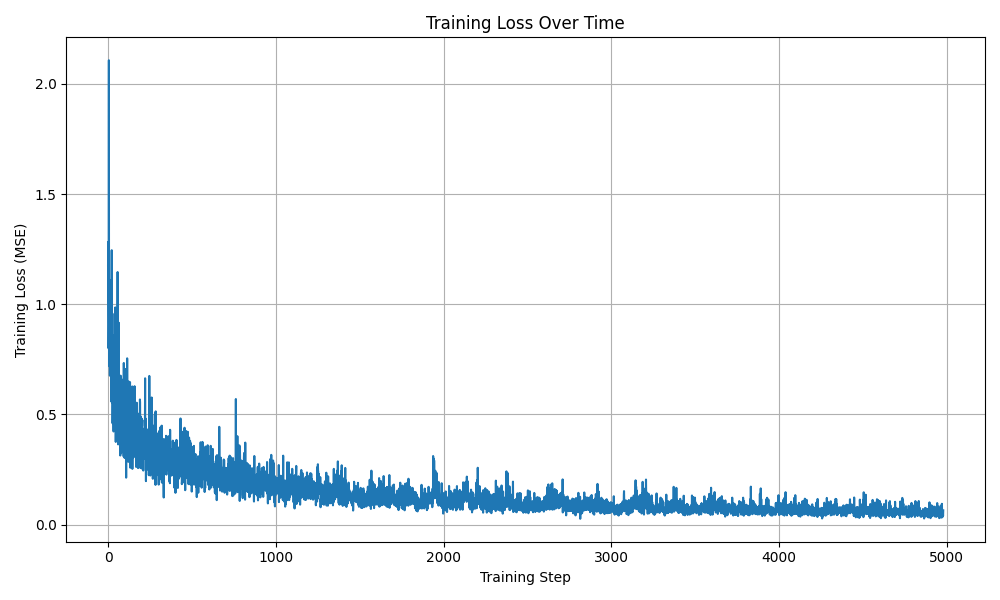

In [25]:
from IPython.display import Image, display

# Display the training history plot
display(Image(filename='training_history.png'))

## 12. Load a Saved Model (Optional)

If you want to resume training or load a previously trained model:

In [26]:
# Example: Load a checkpoint to resume training
# Uncomment and modify the path to your checkpoint

# checkpoint_path = "saved_models/2024-01-29_10-30-45/Epoch_100_GenLoss_0.0123456789.pth"
# resume_epoch = trainer.load_checkpoint(checkpoint_path)
# print(f"Resumed from epoch {resume_epoch}")

# # Continue training from resume_epoch
# for epoch in range(resume_epoch, total_epochs):
#     # ... training loop as above ...

## 12. Final Evaluation and Visualization

Perform a final rollout and create comparison visualizations.

In [27]:
# Final evaluation
model.eval()
target_stats.to("cpu")

true_rollout, pred_rollout = do_rollout(
    model=model,
    test_loader=test_dataloader,
    device=device,
    node_stats=node_stats,
    edge_stats=edge_stats,
    target_stats=target_stats,
    dt=dt,
)

# Compute final metrics
final_rollout_error = mae(true_rollout[-1].x_pos_t, pred_rollout[-1].x_pos_t)
print(f"\nFinal rollout MAE: {final_rollout_error:.6f}")

# Compute per-timestep errors
timestep_errors = []
for true_graph, pred_graph in zip(true_rollout, pred_rollout):
    error = mae(true_graph.x_pos_t, pred_graph.x_pos_t)
    timestep_errors.append(error.item())

plt.figure(figsize=(10, 6))
plt.plot(timestep_errors)
plt.xlabel("Timestep")
plt.ylabel("Position Error (MAE)")
plt.title("Prediction Error Over Rollout")
plt.grid(True)
plt.savefig("rollout_error_over_time.png")
plt.show()

print(f"Average per-timestep error: {np.mean(timestep_errors):.6f}")


Final rollout MAE: 0.040552
Average per-timestep error: 0.017477


In [28]:
# Create final comparison GIF
gif_path = "final_beam_comparison.gif"
volume_png_path = "final_volume_change.png"

plot_volume_change(pred_rollout, true_rollout, path=volume_png_path)
make_beam_comparison_gif(
    pred_rollout=pred_rollout,
    true_rollout=true_rollout,
    L=1.0,
    W=0.1,
    D=0.04,
    out_gif=gif_path,
    fps=4,
    verbose=True,
)

print(f"\nFinal visualizations saved:")
print(f"  - GIF: {gif_path}")
print(f"  - Volume plot: {volume_png_path}")

Rendering frame 0/48


/tmp/ipykernel_323947/3584776946.py:129: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)


Rendering frame 1/48
Rendering frame 2/48
Rendering frame 3/48
Rendering frame 4/48
Rendering frame 5/48
Rendering frame 6/48
Rendering frame 7/48
Rendering frame 8/48
Rendering frame 9/48
Rendering frame 10/48
Rendering frame 11/48
Rendering frame 12/48
Rendering frame 13/48
Rendering frame 14/48
Rendering frame 15/48
Rendering frame 16/48
Rendering frame 17/48
Rendering frame 18/48
Rendering frame 19/48
Rendering frame 20/48
Rendering frame 21/48
Rendering frame 22/48
Rendering frame 23/48
Rendering frame 24/48
Rendering frame 25/48
Rendering frame 26/48
Rendering frame 27/48
Rendering frame 28/48
Rendering frame 29/48
Rendering frame 30/48
Rendering frame 31/48
Rendering frame 32/48
Rendering frame 33/48
Rendering frame 34/48
Rendering frame 35/48
Rendering frame 36/48
Rendering frame 37/48
Rendering frame 38/48
Rendering frame 39/48
Rendering frame 40/48
Rendering frame 41/48
Rendering frame 42/48
Rendering frame 43/48
Rendering frame 44/48
Rendering frame 45/48
Rendering frame 46/

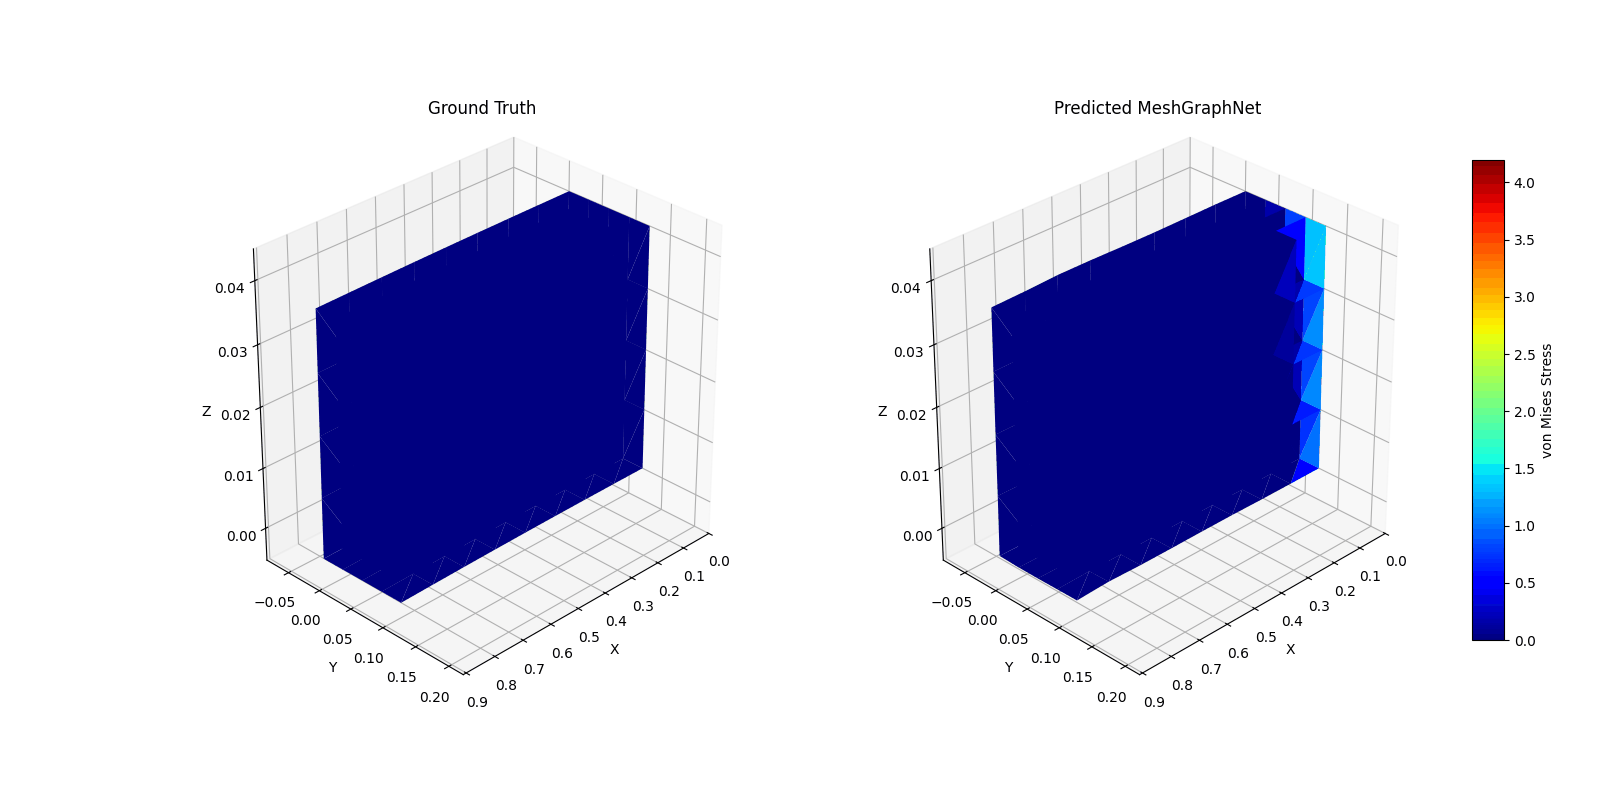

In [29]:
from IPython.display import Image, display

# Display the final comparison GIF
display(Image(filename=gif_path))

The performance will get a lot better with longer epochs and more data. As a next experiment I would reccomend the medium with around 500 epochs. I already did that and it gave good results.

## Summary

This notebook has demonstrated the complete pipeline for training a MeshGraphNet:

1. **Data Preprocessing**: Raw simulation data → Graph format with normalized features
2. **Model Architecture**: MeshGraphNet with encoder-processor-decoder structure
3. **Training**: Supervised learning to predict accelerations and stress
4. **Evaluation**: Autoregressive rollout to test long-term prediction accuracy
5. **Visualization**: Side-by-side comparison GIFs and volume conservation plots

### Key Insights:

- The model learns to predict beam dynamics from graph-structured mesh data
- Message passing allows information to propagate through the mesh
- Normalization is critical for stable training
- Rollout evaluation reveals how errors accumulate over time
- The training uses simple MSE loss between predicted and target accelerations/stress

# Did you notice?
- The model is only trained in the one loading direction and overfitting on that
- **If you run it on the test data you will see it fail completely**
- Maybe this can be fixed with equivariant architectures?

### Some Ideas for Next Steps:

- Explore the data a bit more (exploratory data analysis)
- Train on medium and large dataset
- Create a real validation and test dataset, what makes sense?
- Experiment with different architectures (EGNN, GraphSage, SE(3) transformer, ...)
- Try different loss functions (MAE, Huber loss). I believe MAE should work best
- Try different data normalizations and noise magnitudes
- Experiment with different time integration schemes
- Extend to more complex geometries and loading conditions
- And much more